# Support Vector Machine (SVM)

Support Vector Machine is evaluated under two settings (with and without class imbalance handling), and multiple values of C are tested to determine the best-performing model configuration.

### 1. Import Libraries

Import all the necessary libraries to train the SVM model.

In [1]:
import pickle
import pandas as pd
import numpy as np
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from pathlib import Path

### 2. Define Paths

Declare the path to call the saved tf-idf features. Additionally, define the path to store the results of the training.

In [2]:
FEATURE_DIR = "C:/Users/HP/ecom-reviews-sentiment-analysis/knowledge_representation"
GRAPH_DIR = "C:/Users/HP/ecom-reviews-sentiment-analysis/model_training/results"

#load the tf-idf features
with open(f"{FEATURE_DIR}/tfidf_features.pkl", "rb") as f:
    X_train = pickle.load(f)

with open(f"{FEATURE_DIR}/tfidf_X_val.pkl", "rb") as f:
    X_val = pickle.load(f)
    
with open(f"{FEATURE_DIR}/tfidf_X_test.pkl", "rb") as f:
    X_test = pickle.load(f)

with open(f"{FEATURE_DIR}/y_train.pkl", "rb") as f:
    y_train = pickle.load(f)

with open(f"{FEATURE_DIR}/y_val.pkl", "rb") as f:
    y_val = pickle.load(f)

with open(f"{FEATURE_DIR}/y_test.pkl", "rb") as f:
    y_test = pickle.load(f)

LABEL_NAMES = ["negative", "neutral", "positive"]

OUTPUT_DIR = Path(GRAPH_DIR) / "svm"
OUTPUT_DIR.mkdir(exist_ok=True)

Make sure all the loads are correct

In [3]:
print("Training set")
print("X_train:", X_train.shape)
print("y_train:", len(y_train))

print("\nValidation set")
print("X_val:", X_val.shape)
print("y_val:", len(y_val))

print("\nTest set")
print("X_test:", X_test.shape)
print("y_test:", len(y_test))

Training set
X_train: (428, 1106)
y_train: 428

Validation set
X_val: (92, 1106)
y_val: 92

Test set
X_test: (92, 1106)
y_test: 92


### 3. Class Distribution

Print the total count of positive, negative, and neutral reviews for all three sets (train, test, validation)

In [4]:
#check class distribution
print("Training labels:")
print(pd.Series(y_train).value_counts())

print("\nValidation labels:")
print(pd.Series(y_val).value_counts())

print("\nTest labels:")
print(pd.Series(y_test).value_counts())

Training labels:
sentiment
positive    220
negative    134
neutral      74
Name: count, dtype: int64

Validation labels:
sentiment
positive    48
negative    29
neutral     15
Name: count, dtype: int64

Test labels:
sentiment
positive    47
negative    29
neutral     16
Name: count, dtype: int64


### 4. Evaluation Metrics

Define the function for calling the evaluation metrics funtion.

In [5]:
def evaluate_model(name, model, X_test, y_test):
    """
    Evaluate a trained classifier and return metrics.
    """

    y_pred = model.predict(X_test)

    report = classification_report(
        y_test,
        y_pred,
        target_names=LABEL_NAMES,
        output_dict=True,
        zero_division=0
    )

    accuracy = accuracy_score(y_test, y_pred)

    macro_f1 = f1_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print(f"\n{'='*60}")
    print(f"{name}")
    print(f"{'='*60}")

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=LABEL_NAMES,
            zero_division=0
        )
    )

    metrics = {
        "Model": name,
        "Accuracy": round(accuracy, 4),
        "Macro F1": round(macro_f1, 4),
        "Weighted F1": round(weighted_f1, 4),
        "Negative F1": round(report["negative"]["f1-score"], 4),
        "Neutral F1": round(report["neutral"]["f1-score"], 4),
        "Positive F1": round(report["positive"]["f1-score"], 4),
        "Macro Precision": round(report["macro avg"]["precision"], 4),
        "Macro Recall": round(report["macro avg"]["recall"], 4),
    }

    return metrics, y_pred

### 5. Confusion Matrix

Define the function for confusion matrix.

In [6]:
def plot_confusion_matrix(name, y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=LABEL_NAMES,
        yticklabels=LABEL_NAMES
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.title(f"Confusion Matrix - {name}")

    plt.tight_layout()

    save_path = OUTPUT_DIR / f"cm_{name.lower().replace(' ', '_')}.png"

    plt.savefig(save_path, dpi=300)
    plt.show()

    print(f"Saved confusion matrix to:\n{save_path}")

### 6. Hyperparameter Tuning

Define different C values. Print the accuracy and Macro F1 results for each hyperparameter. Then, Find the settings with the best validation Macro F1 score.

> SVM With Class Imbalance

In [7]:
C_values = [0.01, 0.1, 1, 10]

tuning_results = []

best_C = None
best_macro_f1 = -1

print("=" * 60)
print("SUPPORT VECTOR MACHINE HYPERPARAMETER TUNING (WITH CLASS IMBALANCE)")
print("=" * 60)

for C in C_values:

    model = SVC(
        kernel="linear",
        C=C,
        max_iter=1000,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_val_pred = model.predict(X_val)

    macro_f1 = f1_score(
        y_val,
        y_val_pred,
        average="macro",
        zero_division=0
    )

    accuracy = accuracy_score(y_val, y_val_pred)

    tuning_results.append({
        "C": C,
        "Accuracy": round(accuracy, 4),
        "Macro F1":round(macro_f1, 4)
    })

    print(
        f"C = {C:<5} | "
        f"Accuracy = {accuracy:.4f} | "
        f"Macro F1 = {macro_f1:.4f} | "
    )

    if macro_f1 > best_macro_f1:
        best_macro_f1 = macro_f1
        best_C = C

print("\nBest C:", best_C)
print("\nBest Validation Macro F1:", round(best_macro_f1, 4))

SUPPORT VECTOR MACHINE HYPERPARAMETER TUNING (WITH CLASS IMBALANCE)
C = 0.01  | Accuracy = 0.5217 | Macro F1 = 0.2286 | 
C = 0.1   | Accuracy = 0.5217 | Macro F1 = 0.2286 | 
C = 1     | Accuracy = 0.7174 | Macro F1 = 0.5785 | 
C = 10    | Accuracy = 0.6848 | Macro F1 = 0.5879 | 

Best C: 10

Best Validation Macro F1: 0.5879


> SVM With Class Imbalance Handling

In [8]:
#C_values = [0.01, 0.1, 1, 10]

balanced_tuning_results = []

best_balanced_C = None
best_balanced_macro_f1 = -1

print("=" * 60)
print("SUPPORT VECTOR MACHINE HYPERPARAMETER TUNING (WITH CLASS IMBALANCE HANDLING)")
print("=" * 60)

for C in C_values:

    balanced_model = SVC(
        kernel="linear",
        C=C,
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    )

    balanced_model.fit(X_train, y_train)

    y_val_pred = balanced_model.predict(X_val)

    balanced_macro_f1 = f1_score(
        y_val,
        y_val_pred,
        average="macro",
        zero_division=0
    )

    balanced_accuracy = accuracy_score(y_val, y_val_pred)

    balanced_tuning_results.append({
        "C": C,
        "Accuracy": round(balanced_accuracy, 4),
        "Macro F1":round(balanced_macro_f1, 4)
    })

    print(
        f"C = {C:<5} | "
        f"Accuracy = {balanced_accuracy:.4f} | "
        f"Macro F1 = {balanced_macro_f1:.4f} | "
    )

    if macro_f1 > best_balanced_macro_f1:
        best_balanced_macro_f1 = balanced_macro_f1
        best_balanced_C = C

print("\nBest C:", best_balanced_C)
print("\nBest Validation Macro F1:", round(best_balanced_macro_f1, 4))

SUPPORT VECTOR MACHINE HYPERPARAMETER TUNING (WITH CLASS IMBALANCE HANDLING)
C = 0.01  | Accuracy = 0.1630 | Macro F1 = 0.0935 | 
C = 0.1   | Accuracy = 0.1630 | Macro F1 = 0.0935 | 
C = 1     | Accuracy = 0.6957 | Macro F1 = 0.5988 | 
C = 10    | Accuracy = 0.6848 | Macro F1 = 0.5879 | 

Best C: 1

Best Validation Macro F1: 0.5988


### 7. Validation Results

Print the tuned model accuracy and Macro F1 results.

> SVM With Class Imbalance

In [9]:
tuning_df = pd.DataFrame(tuning_results)

print("=" * 30)
print("Validation Results (With Class Imbalance)")
print("=" * 30)
print(tuning_df.sort_values("Macro F1", ascending=True))

Validation Results (With Class Imbalance)
       C  Accuracy  Macro F1
0   0.01    0.5217    0.2286
1   0.10    0.5217    0.2286
2   1.00    0.7174    0.5785
3  10.00    0.6848    0.5879


> SVM With Class Imbalance Handling

In [10]:
balanced_tuning_df = pd.DataFrame(balanced_tuning_results)

print("=" * 30)
print("Validation Results (With Class Imbalance Handling)")
print("=" * 30)
print(balanced_tuning_df.sort_values("Macro F1", ascending=True))

Validation Results (With Class Imbalance Handling)
       C  Accuracy  Macro F1
0   0.01    0.1630    0.0935
1   0.10    0.1630    0.0935
3  10.00    0.6848    0.5879
2   1.00    0.6957    0.5988


### 8. Train Final Model

Train the final model using the best C value.

>SVM WIth Class Imbalance

In [11]:
svm_model = SVC(
    kernel="linear",
    C=best_C,
    max_iter=1000,
    probability=True,
    random_state=42
)

svm_model.fit(X_train, y_train)

print(f"\nFinal model trained with C = {best_C}")

c:\Users\HP\ecom-reviews-sentiment-analysis\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



Final model trained with C = 10


> SVM With Class Imbalance Handling

In [12]:
balanced_svm_model = SVC(
    kernel="linear",
    C=best_balanced_C,
    max_iter=1000,
    probability=True,
    class_weight="balanced",
    random_state=42
)

balanced_svm_model.fit(X_train, y_train)

print(f"\nFinal model trained with C = {best_balanced_C}")

c:\Users\HP\ecom-reviews-sentiment-analysis\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



Final model trained with C = 1


### 9. Evaluate Test Set

Test the trained model on the test dataset. Record the results.


SVM With Class Imbalance(C=10)
              precision    recall  f1-score   support

    negative       0.68      0.66      0.67        29
     neutral       0.25      0.12      0.17        16
    positive       0.79      0.94      0.85        47

    accuracy                           0.71        92
   macro avg       0.57      0.57      0.56        92
weighted avg       0.66      0.71      0.68        92



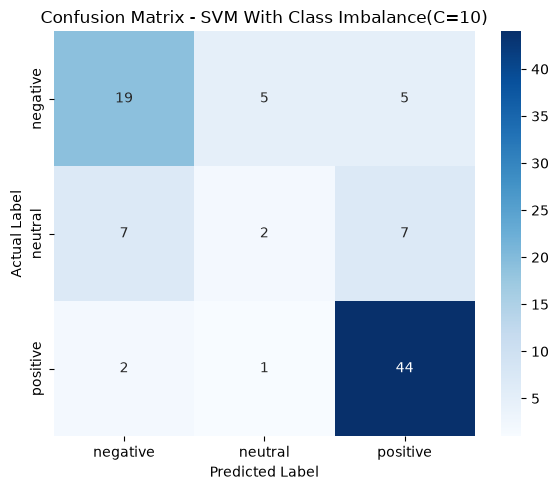

Saved confusion matrix to:
C:\Users\HP\ecom-reviews-sentiment-analysis\model_training\results\svm\cm_svm_with_class_imbalance(c=10).png

SVM With Class Imbalance Handling(C=1)
              precision    recall  f1-score   support

    negative       0.71      0.69      0.70        29
     neutral       0.33      0.25      0.29        16
    positive       0.81      0.89      0.85        47

    accuracy                           0.72        92
   macro avg       0.62      0.61      0.61        92
weighted avg       0.70      0.72      0.70        92



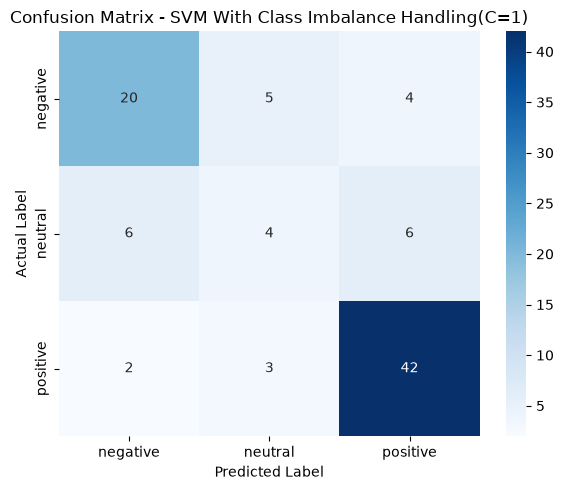

Saved confusion matrix to:
C:\Users\HP\ecom-reviews-sentiment-analysis\model_training\results\svm\cm_svm_with_class_imbalance_handling(c=1).png


In [13]:
all_test_results = []

#Model with class imbalance
test_metrics_1, y_test_pred_1 = evaluate_model(
    f"SVM With Class Imbalance(C={best_C})",
    svm_model,
    X_test,
    y_test
)

plot_confusion_matrix(
    f"SVM With Class Imbalance(C={best_C})",
    y_test,
    y_test_pred_1
)

all_test_results.append(test_metrics_1)

# Model with class imbalance handling
test_metrics_2, y_test_pred_2 = evaluate_model(
    f"SVM With Class Imbalance Handling(C={best_balanced_C})",
    balanced_svm_model,
    X_test,
    y_test
)

plot_confusion_matrix(
    f"SVM With Class Imbalance Handling(C={best_balanced_C})",
    y_test,
    y_test_pred_2
)

all_test_results.append(test_metrics_2)

### 10. Print Test Results

Print and compare the test results for SVM on test set.

In [14]:
results_df = pd.DataFrame(all_test_results)

print("=" * 30)
print("Final Test Results")
print("=" * 30)

print(results_df.T)

Final Test Results
                                              0  \
Model            SVM With Class Imbalance(C=10)   
Accuracy                                 0.7065   
Macro F1                                 0.5626   
Weighted F1                              0.6756   
Negative F1                              0.6667   
Neutral F1                               0.1667   
Positive F1                              0.8544   
Macro Precision                          0.5714   
Macro Recall                             0.5721   

                                                      1  
Model            SVM With Class Imbalance Handling(C=1)  
Accuracy                                         0.7174  
Macro F1                                          0.612  
Weighted F1                                      0.7044  
Negative F1                                      0.7018  
Neutral F1                                       0.2857  
Positive F1                                      0.8485  
Macro 

### 11. Save the Model

Save the final trained Support Vector Machine model.

In [15]:
best_svm_model = balanced_svm_model

with open(OUTPUT_DIR / "svm_model.pkl", "wb") as f:
    pickle.dump(svm_model, f)

print("Support Vector Machine model saved!")

Support Vector Machine model saved!


### 12. Quick Prediction Test

In [16]:
MODEL_PATH = Path("C:/Users/HP/ecom-reviews-sentiment-analysis/model_training/results/svm/svm_model.pkl")
VECTORIZER_PATH = Path("C:/Users/HP/ecom-reviews-sentiment-analysis/knowledge_representation/vectorizer.pkl")

with open(MODEL_PATH, "rb") as f:
    model = pickle.load(f)

with open(VECTORIZER_PATH, "rb") as f:
    vectorizer = pickle.load(f)

LABEL_NAMES = ["negative", "neutral", "positive"]

# Give a new review that the model has not been exposed to yet
new_review = "not good quality and delivery was slow."

X_new = vectorizer.transform([new_review])

probs = model.predict_proba(X_new)[0]
predicted_index = probs.argmax()
predicted_label = LABEL_NAMES[predicted_index]
confidence = probs[predicted_index]

print("Predicted label:", predicted_label)
print(f"Confidence: {confidence:.4f}")
print("Probabilities:")
for label, p in zip(LABEL_NAMES, probs):
    print(f"  {label}: {p:.4f}")

Predicted label: negative
Confidence: 0.8481
Probabilities:
  negative: 0.8481
  neutral: 0.1226
  positive: 0.0292
